In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
from collections import defaultdict

sys.path.append("./../../")
from utils_v2 import *
from utils_data_v2 import *

In [3]:
x = [1,2]
b = x if isinstance(x, list) else [x]
print(b)

[1, 2]


In [1]:
max([10,2])

10

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import argparse

save_dir = './results/dummy_results'
df = pd.read_csv(os.path.join(save_dir, 'r_p.csv')) 

In [5]:
df

,SE_Y0_r,SE_Y0_p,SE_Y1_r,SE_Y1_p,SE_A_r,SE_A_p,SE_S_r,SE_S_p
0,-0.026534,0.401923,-0.012349,0.696512,-0.025971,0.411991,-0.023697,0.454130
1,0.061860,0.050512,0.085082,0.007101,0.086200,0.006381,-0.003549,0.910752
2,0.000814,0.979493,0.004191,0.894694,0.136569,0.000015,0.035364,0.263884
3,-0.023557,0.456818,0.108253,0.000606,0.068755,0.029699,-0.031143,0.325200
4,-0.010661,0.736324,0.049732,0.116027,0.053209,0.092629,0.008245,0.794553
...,...,...,...,...,...,...,...,...
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
np.random.seed(42)

n_rct, n_rct_val = 20000, 10000
n_obs, n_obs_val = 20000, 10000
n_val = 1000

pl_range = (0.1, 0.2)
ph_range = (0.8, 0.9)

d = 5
d_meas = d - 1
predictors = [f"Xp{i + 1}" for i in range(2 ** d_meas)]

scenario = {"Y0": None, "Y1": "biased", "A": None, "S": "biased"}
pU_R0, pU_R1 = 0.2, 0.8  # for transportability of 

cov_res = defaultdict(lambda: defaultdict(list))
num_trials = 20

for _ in range(num_trials):
    obs_probs = sample_all_probs(d, pl_range, ph_range, scenario)
    rct_probs = {"Y0": obs_probs["Y0"],
                "Y1": obs_probs["Y1"], 
                "A": (2 ** d) * [0.5],
                "S": (2 ** d) * [0.95],}

    df_rct     = init_df(n_rct, d, d_meas, 1, rct_probs)
    df_obs     = init_df(n_obs, d, d_meas, 0, obs_probs)
    df_rct_val = init_df(n_rct_val, d, d_meas, 1, rct_probs)
    df_obs_val = init_df(n_obs_val, d, d_meas, 0, obs_probs)

    rct_models = fit_models(df_rct, predictors)
    make_preds(df_rct_val, predictors, rct_models)
    
    obs_models = fit_models(df_obs, predictors)
    make_preds(df_obs_val, predictors, obs_models)

    pr_model = fit_model(pd.concat([df_rct, df_obs]), predictors, "R")
    df_val = merge_df_val(df_rct_val, df_obs_val, predictors, pr_model, rct_models, obs_models)


    for key in ["SE_Y0", "SE_Y1", "SE_A", "SE_S"]:
        cov_res["Pearson"][key].append(pearsonr(df_val, "abs(b1(X))", key, n_val))


In [25]:
res_keys = ["SE_Y0", "SE_Y1", "SE_A", "SE_S"]

In [33]:
[key + suffix for key in res_keys for suffix in ["_r", "_p"]]

['SE_Y0_r',
 'SE_Y0_p',
 'SE_Y1_r',
 'SE_Y1_p',
 'SE_A_r',
 'SE_A_p',
 'SE_S_r',
 'SE_S_p']

In [6]:
mse_s_y = list()
mse_s_a = list()
mse_s_s = list()

for i in range(2 ** d_meas):
    mse_s_y.append(df_val.query(f"Xp{i + 1}==1")["SE_Y1"].mean())
    mse_s_a.append(df_val.query(f"Xp{i + 1}==1")["SE_A"].mean())
    mse_s_s.append(df_val.query(f"Xp{i + 1}==1")["SE_S"].mean())

df_val["MSE_Y1"] = df_val.apply(lambda row: mse_s_y[np.where(np.array(row[predictors])==1)[0][0]],axis=1)
df_val["MSE_A"] = df_val.apply(lambda row: mse_s_a[np.where(np.array(row[predictors])==1)[0][0]],axis=1)
df_val["MSE_S"] = df_val.apply(lambda row: mse_s_s[np.where(np.array(row[predictors])==1)[0][0]],axis=1)

In [ ]:
plt.scatter(df_val.query("R==0")["MSE_S"], df_val.query("R==0")["abs(b1(X))"], s=2)
plt.scatter(df_val.query("R==0")["MSE_Y1"], df_val.query("R==0")["abs(b1(X))"],s=2)
plt.scatter(df_val.query("R==0")["MSE_A"], df_val.query("R==0")["abs(b1(X))"])

In [ ]:
cp = sns.color_palette("tab10")
fig, axs = plt.subplots(2, 2, figsize=(10,8)) 

for idx, key in enumerate(cov_res["Pearson"]):
    i = idx // 2
    j = idx % 2

    axs[i, j].set_title(f"Cov($b1(X)$, {key})", fontsize=16)
    axs[i, j].axhline(y=-np.log10(0.05), color='dimgray', linestyle='--', label='p = 0.05')
    
    arr = np.array(cov_res["Pearson"][key])
    hat_cov = arr[:, 0]
    log_p_val = np.clip(-np.log10(arr[:, 1]), a_min=None, a_max=5)
    axs[i, j].scatter(hat_cov, log_p_val, color=cp[idx], s=16, alpha=1)

axs[0,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_xlabel("Pearson's R", fontsize=16)
axs[1,1].set_xlabel("Pearson's R", fontsize=16)

print("HEY")
plt.show()

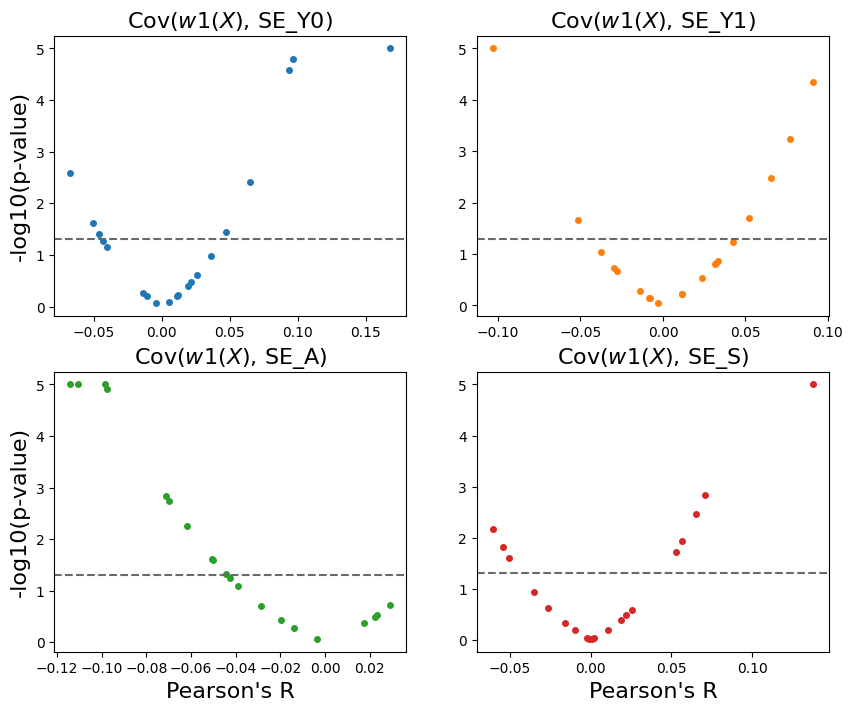

In [13]:
cp = sns.color_palette("tab10")
fig, axs = plt.subplots(2, 2, figsize=(10,8)) 

for idx, key in enumerate(cov_res["Pearson"]):
    i = idx // 2
    j = idx % 2

    axs[i, j].set_title(f"Cov($b1(X)$, {key})", fontsize=16)
    axs[i, j].axhline(y=-np.log10(0.05), color='dimgray', linestyle='--', label='p = 0.05')
    
    arr = np.array(cov_res["Pearson"][key])
    hat_cov = arr[:, 0]
    log_p_val = np.clip(-np.log10(arr[:, 1]), a_min=None, a_max=5)
    axs[i, j].scatter(hat_cov, log_p_val, color=cp[idx], s=16, alpha=1)

axs[0,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_xlabel("Pearson's R", fontsize=16)
axs[1,1].set_xlabel("Pearson's R", fontsize=16)

plt.show()

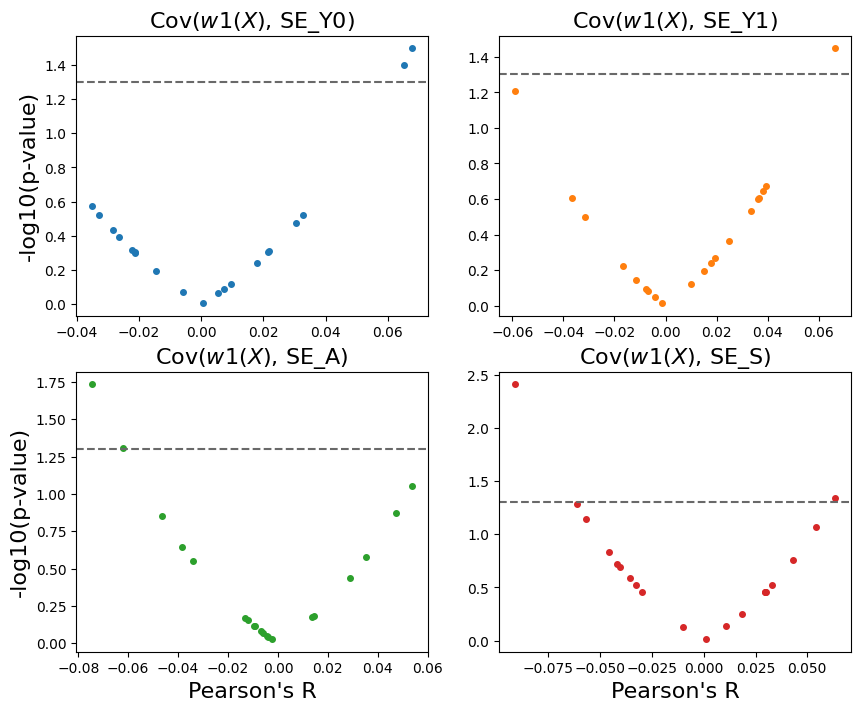

In [9]:
cp = sns.color_palette("tab10")
fig, axs = plt.subplots(2, 2, figsize=(10,8)) 

for idx, key in enumerate(cov_res["Pearson"]):
    i = idx // 2
    j = idx % 2

    axs[i, j].set_title(f"Cov($b1(X)$, {key})", fontsize=16)
    axs[i, j].axhline(y=-np.log10(0.05), color='dimgray', linestyle='--', label='p = 0.05')
    
    arr = np.array(cov_res["Pearson"][key])
    hat_cov = arr[:, 0]
    log_p_val = np.clip(-np.log10(arr[:, 1]), a_min=None, a_max=5)
    axs[i, j].scatter(hat_cov, log_p_val, color=cp[idx], s=16, alpha=1)

axs[0,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_xlabel("Pearson's R", fontsize=16)
axs[1,1].set_xlabel("Pearson's R", fontsize=16)

plt.show()